# Student Dropout Prediction

**Programming in Python — Final-Term Project (Summer 25-26)**

**Pathway:** Classification

**Dataset:** UCI Machine Learning Repository #697 (CC BY 4.0)

**Group Members:**
- SOUMIK DAS DIPON – 23-51709-2
- MD. MAHABUBUR RAHAMAN SIAM – 23-51706-2
- DIPU ROY – 23-50420-1
- NAHIDUL HASSAN – 22-49252-3

## 1. Setup

We import libraries, set a random seed for reproducibility, and print package versions.

In [ ]:
# ============================================================
# 1. SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, average_precision_score)

import warnings
warnings.filterwarnings("ignore")
import sys, sklearn

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Show versions
print("Python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.13.15
numpy       : 2.1.3
pandas      : 2.2.3
scikit-learn: 1.6.1


## 2. Problem Formulation (DW-1)

**Question:** Can we predict which students are likely to drop out using information from their first year?

**Unit of analysis:** One student (one row = one student).

**Target:** `Target` — 3 classes: Dropout, Enrolled, Graduate.

**Stakeholders:** Student support office, students, university management.

**Success criteria:**
- Beat the majority-class baseline on macro-F1
- Catch at least 70% of real dropouts

**Not to be used for:** Any automatic decision against a student. Only for offering support.

## 3. Data Loading (DW-2)

**Source:** UCI Machine Learning Repository, Dataset #697

**Link:** https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

**License:** CC BY 4.0

**Citation:** Realinho, V., et al. (2021). UCI ML Repository. DOI: 10.24432/C5MC89

In [ ]:
# ============================================================
# 3. LOAD DATA
# ============================================================
import urllib.request, shutil
from pathlib import Path

Path("data").mkdir(exist_ok=True)
zip_path = Path("data/students.zip")

if not zip_path.exists():
    print("Downloading dataset from UCI...")
    url = "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=60) as r, open(zip_path, "wb") as f:
        shutil.copyfileobj(r, f)
    print("Download complete.")
else:
    print("Dataset already downloaded.")

df = pd.read_csv(zip_path, sep=";", encoding="utf-8-sig")

print("\nShape:", df.shape)
df.head()

Download complete.

Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate






## 4. Data Audit (DW-3)

Check missing values, duplicates, target distribution, and value ranges.

In [ ]:
# ============================================================
# 4. DATA AUDIT
# ============================================================
print("=== Missing Values ===")
print("Total missing cells:", df.isnull().sum().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())

print("\n=== Target Distribution ===")
print(df["Target"].value_counts())
print("\nProportions:")
print(df["Target"].value_counts(normalize=True).round(3))

print("\n=== Value Ranges ===")
print("Age:", df["Age at enrollment"].min(), "-", df["Age at enrollment"].max())
print("Admission grade:", df["Admission grade"].min(), "-", df["Admission grade"].max())

=== Missing Values ===
Total missing cells: 0

=== Duplicate Rows ===
Duplicates: 0

=== Target Distribution ===
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proportions:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

=== Value Ranges ===
Age: 17 - 70
Admission grade: 95.0 - 190.0


## 5. Clean Column Names + Encode Target

Two fixes:
1. Rename columns to snake_case
2. Convert target text to numbers (0/1/2)

In [ ]:
# ============================================================
# 5. CLEAN NAMES + ENCODE TARGET
# ============================================================
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r"[^a-z0-9]+", "_", regex=True)
              .str.strip("_"))

TARGET_MAP = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
CLASS_NAMES = ["Dropout", "Enrolled", "Graduate"]

df["outcome"] = df["target"]
df["target"] = df["target"].map(TARGET_MAP)

print("Encoded values:", sorted(df["target"].unique()))
print("\nClass counts:")
print(df["target"].value_counts().sort_index()
      .rename(index={0: "Dropout", 1: "Enrolled", 2: "Graduate"}))

Encoded values: [np.int64(0), np.int64(1), np.int64(2)]

Class counts:
target
Dropout     1421
Enrolled     794
Graduate    2209
Name: count, dtype: int64


## 6. Exploratory Data Analysis (DW-4)

Three plots to understand the data:
1. Class distribution
2. Units passed by outcome
3. Dropout rate by tuition status

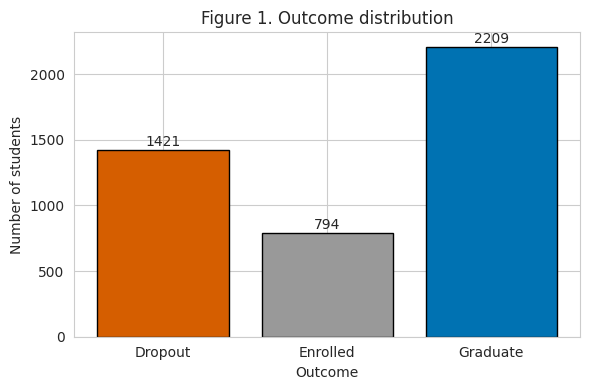

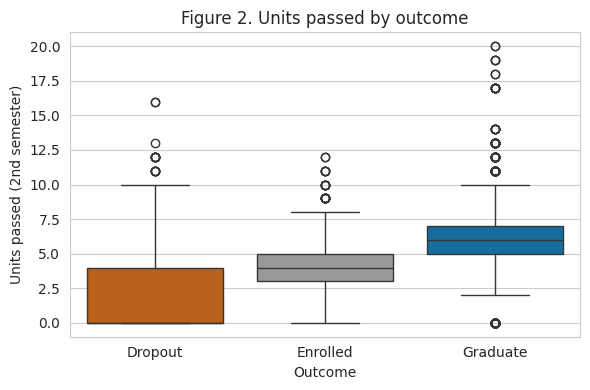

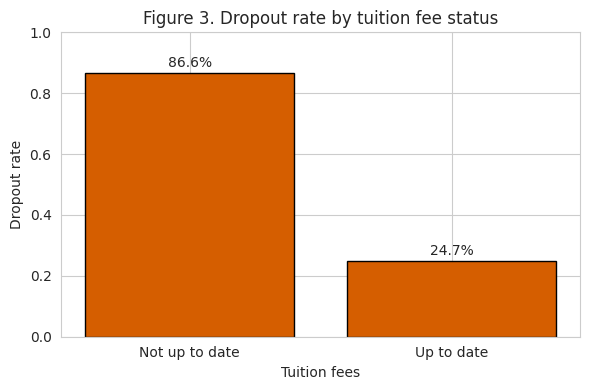


Median units passed by outcome:
outcome
Dropout     0.0
Enrolled    4.0
Graduate    6.0
Name: curricular_units_2nd_sem_approved, dtype: float64


In [ ]:
# ============================================================
# 6. EDA — 3 informative plots
# ============================================================
CLASS_ORDER = ["Dropout", "Enrolled", "Graduate"]
COLORS = {"Dropout": "#D55E00", "Enrolled": "#999999", "Graduate": "#0072B2"}

# Plot 1: Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["outcome"].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(CLASS_ORDER, counts.values, color=[COLORS[c] for c in CLASS_ORDER], edgecolor="black")
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, n + 30, f"{n}", ha="center")
ax.set(title="Figure 1. Outcome distribution",
       xlabel="Outcome", ylabel="Number of students")
plt.tight_layout()
plt.show()

# Plot 2: Units passed in 2nd semester by outcome
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="outcome", y="curricular_units_2nd_sem_approved",
            order=CLASS_ORDER, palette=COLORS, ax=ax)
ax.set(title="Figure 2. Units passed by outcome",
       xlabel="Outcome", ylabel="Units passed (2nd semester)")
plt.tight_layout()
plt.show()

# Plot 3: Dropout rate by tuition status
fig, ax = plt.subplots(figsize=(6, 4))
dropout_rate = df.groupby("tuition_fees_up_to_date")["outcome"].apply(
    lambda s: (s == "Dropout").mean())
labels = ["Not up to date", "Up to date"]
ax.bar(labels, dropout_rate.values, color="#D55E00", edgecolor="black")
for i, v in enumerate(dropout_rate.values):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
ax.set(title="Figure 3. Dropout rate by tuition fee status",
       xlabel="Tuition fees", ylabel="Dropout rate", ylim=(0, 1))
plt.tight_layout()
plt.show()

print("\nMedian units passed by outcome:")
print(df.groupby("outcome")["curricular_units_2nd_sem_approved"].median().reindex(CLASS_ORDER))

## 7. Train/Test Split (DW-5) — BEFORE Preprocessing

Critical rule: Split FIRST, preprocess LATER. This prevents data leakage.
- 80% training, 20% testing
- Stratified (keeps class proportions equal)
- Random state = 42

In [ ]:
# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================
X = df.drop(columns=["target", "outcome"])
y = df["target"]

print("Total features:", X.shape[1])
print("Total students:", X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTrain size: {len(X_train)} students")
print(f"Test  size: {len(X_test)} students")
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3).rename(
    index={0: "Dropout", 1: "Enrolled", 2: "Graduate"}))


Total features: 36
Total students: 4424

Train size: 3539 students
Test  size: 885 students

Train class distribution:
target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


## 8. Preprocessing Pipeline (DW-6)

Two steps inside a Pipeline:
1. Fill missing values with median (learned from training data only)
2. Scale features

In [ ]:
# ============================================================
# 8. PREPROCESSING PIPELINE
# ============================================================
preprocessor = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])

print("Preprocessor steps:")
print("  1. Impute missing with median")
print("  2. Standard scaling")

Preprocessor steps:
  1. Impute missing with median
  2. Standard scaling


## 9. Baseline (DW-7)

The simplest model: always predict majority class (Graduate).
We use macro-F1 because classes are imbalanced.

In [ ]:
# ============================================================
# 9. BASELINE
# ============================================================
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("=== BASELINE (majority class) ===")
print("Accuracy  :", round(accuracy_score(y_test, y_pred_base), 3))
print("Macro-F1  :", round(f1_score(y_test, y_pred_base, average="macro"), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))

=== BASELINE (majority class) ===
Accuracy  : 0.499
Macro-F1  : 0.222

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.00      0.00      0.00       284
    Enrolled       0.00      0.00      0.00       159
    Graduate       0.50      1.00      0.67       442

    accuracy                           0.50       885
   macro avg       0.17      0.33      0.22       885
weighted avg       0.25      0.50      0.33       885



## 10. Candidate Models + Cross-Validation (DW-8)

Two models:
- Logistic Regression — simple, interpretable
- Random Forest — handles non-linear patterns

Both use class_weight='balanced'. 5-fold CV on training data only.

In [ ]:
# ============================================================
# 10. TRAIN TWO MODELS + CROSS-VALIDATION
# ============================================================
lr_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000,
                               class_weight="balanced",
                               random_state=RANDOM_STATE))
])

rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100,
                                   max_depth=10,
                                   class_weight="balanced",
                                   random_state=RANDOM_STATE,
                                   n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Running 5-fold cross-validation on TRAINING set...\n")
cv_scores = {}
for name, model in [("Logistic Regression", lr_pipeline),
                    ("Random Forest", rf_pipeline)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring="f1_macro", n_jobs=-1)
    cv_scores[name] = scores.mean()
    print(f"{name:25s} CV Macro-F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print("\nBoth models fitted on the full training set.")

Running 5-fold cross-validation on TRAINING set...

Logistic Regression       CV Macro-F1 = 0.704 (+/- 0.012)
Random Forest             CV Macro-F1 = 0.713 (+/- 0.016)

Both models fitted on the full training set.


In [ ]:
# ============================================================
# Pick final model
# ============================================================
FINAL_MODEL_NAME = max(cv_scores, key=cv_scores.get)
final_model = lr_pipeline if FINAL_MODEL_NAME == "Logistic Regression" else rf_pipeline

print(f"Final model: {FINAL_MODEL_NAME}")
print(f"CV Macro-F1: {cv_scores[FINAL_MODEL_NAME]:.3f}")

Final model: Random Forest
CV Macro-F1: 0.713


## 11. Final Evaluation on Test Set (DW-9)

This is the first and ONLY time we look at the test set.

In [ ]:
# ============================================================
# 11. FINAL EVALUATION
# ============================================================
y_pred = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)

print(f"=== {FINAL_MODEL_NAME} — Test Results ===\n")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Macro-F1 :", round(f1_score(y_test, y_pred, average="macro"), 3))

auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
ap  = average_precision_score((y_test == 0).astype(int), proba[:, 0])
print("ROC-AUC (macro, OvR):", round(auc, 3))
print("Dropout PR-AUC      :", round(ap, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

=== Random Forest — Test Results ===

Accuracy : 0.751
Macro-F1 : 0.702
ROC-AUC (macro, OvR): 0.887
Dropout PR-AUC      : 0.872

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.69      0.76       284
    Enrolled       0.46      0.56      0.50       159
    Graduate       0.83      0.86      0.85       442

    accuracy                           0.75       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.77      0.75      0.76       885



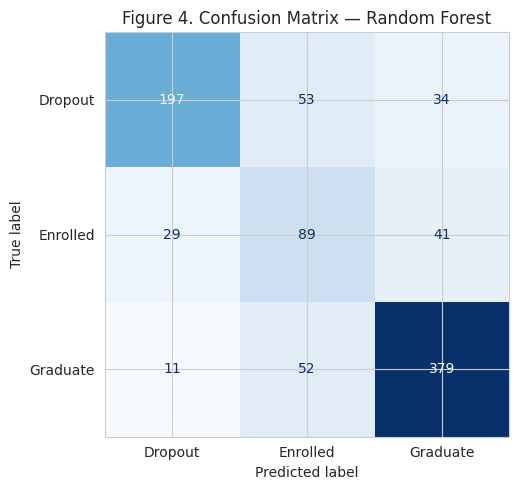

In [ ]:
# ============================================================
# Confusion Matrix (Figure 4)
# ============================================================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Figure 4. Confusion Matrix — {FINAL_MODEL_NAME}")
plt.tight_layout()
plt.show()

## 12. Error Analysis (DW-10)

The most harmful error is a false negative — a real dropout we missed.

In [ ]:
# ============================================================
# 12. ERROR ANALYSIS
# ============================================================
cm = confusion_matrix(y_test, y_pred)
missed_dropouts = cm[0, 1] + cm[0, 2]
total_dropouts  = cm[0, :].sum()

print(f"True dropouts in test set : {total_dropouts}")
print(f"Dropouts MISSED (FN)      : {missed_dropouts}")
print(f"Dropouts CAUGHT           : {total_dropouts - missed_dropouts}")
print(f"Dropout recall            : {(total_dropouts - missed_dropouts) / total_dropouts:.3f}")

print("\nFindings:")
print("- Graduate class is predicted best")
print("- Enrolled is the hardest (in-between state)")
print("- Most errors: real Graduates/Dropouts predicted as Enrolled")


True dropouts in test set : 284
Dropouts MISSED (FN)      : 87
Dropouts CAUGHT           : 197
Dropout recall            : 0.694

Findings:
- Graduate class is predicted best
- Enrolled is the hardest (in-between state)
- Most errors: real Graduates/Dropouts predicted as Enrolled


## 13. Feature Importance

Which features does the model rely on most?

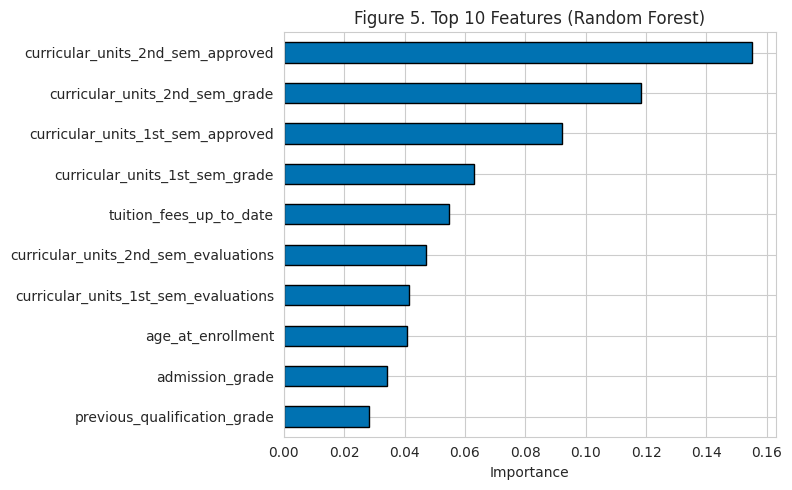

Top 5 features:
curricular_units_2nd_sem_approved    0.1552
curricular_units_2nd_sem_grade       0.1184
curricular_units_1st_sem_approved    0.0922
curricular_units_1st_sem_grade       0.0631
tuition_fees_up_to_date              0.0547
dtype: float64


In [ ]:
# ============================================================
# 13. FEATURE IMPORTANCE (Figure 5)
# ============================================================
importances = pd.Series(
    rf_pipeline.named_steps["clf"].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
importances.iloc[::-1].plot(kind="barh", color="#0072B2", edgecolor="black", ax=ax)
ax.set_title("Figure 5. Top 10 Features (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.head(5).round(4))

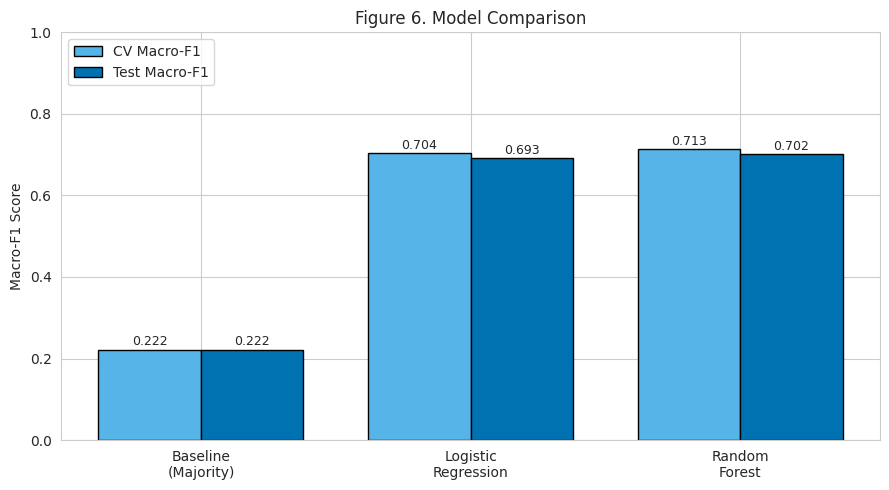

In [ ]:
# ============================================================
# Figure 6: Model Comparison
# ============================================================
model_names = ["Baseline\n(Majority)", "Logistic\nRegression", "Random\nForest"]
cv_f1_scores = [0.222, cv_scores["Logistic Regression"], cv_scores["Random Forest"]]
test_f1_scores = [f1_score(y_test, y_pred_base, average="macro"),
                  f1_score(y_test, lr_pipeline.predict(X_test), average="macro"),
                  f1_score(y_test, y_pred, average="macro")]

x = np.arange(len(model_names))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, cv_f1_scores, width, label="CV Macro-F1", color="#56B4E9", edgecolor="black")
ax.bar(x + width/2, test_f1_scores, width, label="Test Macro-F1", color="#0072B2", edgecolor="black")

for i, (cv, ts) in enumerate(zip(cv_f1_scores, test_f1_scores)):
    ax.text(i - width/2, cv + 0.01, f"{cv:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, ts + 0.01, f"{ts:.3f}", ha="center", fontsize=9)

ax.set(title="Figure 6. Model Comparison", ylabel="Macro-F1 Score", ylim=(0, 1))
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

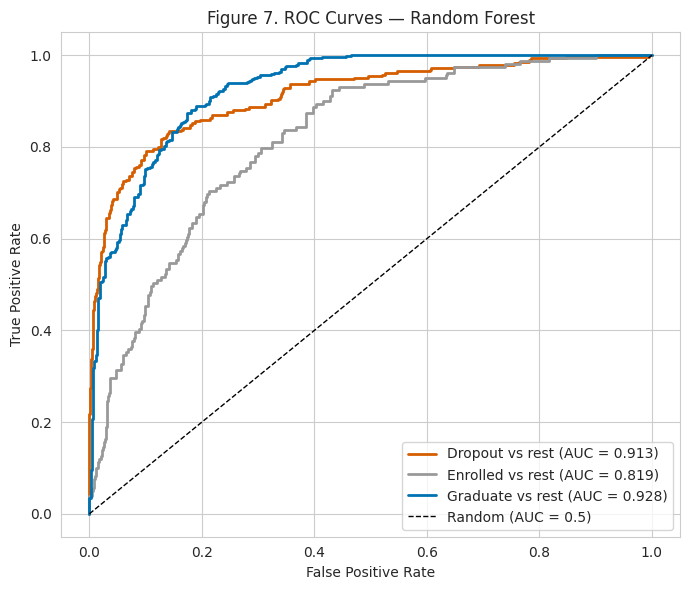

In [ ]:
# ============================================================
# Figure 7: ROC Curves
# ============================================================
from sklearn.metrics import roc_curve, auc as auc_function
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
proba_full = final_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ["#D55E00", "#999999", "#0072B2"]

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_score = auc_function(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{cls} vs rest (AUC = {auc_score:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.5)")
ax.set(title="Figure 7. ROC Curves — Random Forest",
       xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 14. Conclusion

What we did:
- Loaded 4,424 students from UCI #697
- Split 80/20 stratified
- Compared baseline vs LR vs RF
- 5-fold CV on training data
- Evaluated ONCE on the test set

Findings:
- Both models beat baseline clearly
- Top features: first-year results, tuition, course
- Enrolled is hardest to predict

Responsible use: Only for offering support — never for punishment.

Limitations: One institution, "Dropout" includes transfers.

Future work: Gradient boosting; time-based split; behavioural data.

In [ ]:
# ============================================================
# 15. SAVE OUTPUTS
# ============================================================
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)

req = f"""numpy=={np.__version__}
pandas=={pd.__version__}
scikit-learn=={sklearn.__version__}
matplotlib=={plt.matplotlib.__version__}
"""
Path("outputs/requirements.txt").write_text(req)
print("Saved outputs/requirements.txt")

results_text = f"""
FINAL RESULTS SUMMARY
=====================
Dataset      : UCI #697 Student Dropout (4,424 students)
Split        : 80/20 stratified, random_state=42
Final model  : {FINAL_MODEL_NAME}

Test Results
------------
Accuracy     : {accuracy_score(y_test, y_pred):.3f}
Macro-F1     : {f1_score(y_test, y_pred, average='macro'):.3f}
ROC-AUC      : {auc:.3f}
Dropout PR-AUC: {ap:.3f}
Baseline F1  : {f1_score(y_test, y_pred_base, average='macro'):.3f}

Per-class F1
------------
Dropout  : {f1_score(y_test, y_pred, average=None)[0]:.3f}
Enrolled : {f1_score(y_test, y_pred, average=None)[1]:.3f}
Graduate : {f1_score(y_test, y_pred, average=None)[2]:.3f}
"""
Path("outputs/results_summary.txt").write_text(results_text)
print("Saved outputs/results_summary.txt")
print(results_text)

Saved outputs/requirements.txt
Saved outputs/results_summary.txt

FINAL RESULTS SUMMARY
Dataset      : UCI #697 Student Dropout (4,424 students)
Split        : 80/20 stratified, random_state=42
Final model  : Random Forest
 
Test Results
------------
Accuracy     : 0.751
Macro-F1     : 0.702
ROC-AUC      : 0.887
Dropout PR-AUC: 0.872
Baseline F1  : 0.222
 
Per-class F1
------------
Dropout  : 0.756
Enrolled : 0.504
Graduate : 0.846



In [ ]:
# ============================================================
# Create README.md
# ============================================================
readme = """# Student Dropout Prediction

## Group
- SOUMIK DAS DIPON - 23-51709-2
- MD. MAHABUBUR RAHAMAN SIAM - 23-51706-2
- DIPU ROY - 23-50420-1
- NAHIDUL HASSAN - 22-49252-3

## Setup
1. Open in Google Colab
2. Runtime -> Restart and run all
3. Dataset downloads automatically from UCI

## Files
- data/students.zip - raw data
- outputs/requirements.txt - package versions
- outputs/results_summary.txt - final metrics

## Data Source
UCI ML Repository, Dataset #697
License: CC BY 4.0

## Reference
Realinho, V., et al. (2021). UCI ML Repository. DOI: 10.24432/C5MC89
"""
Path("README.md").write_text(readme)
print("README.md created")

README.md created


## 16. References + Contribution

### References

1. Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI ML Repository. https://doi.org/10.24432/C5MC89 (CC BY 4.0)

2. Realinho, V., et al. (2022). Predicting Student Dropout and Academic Success. *Data, 7*(11), 146.

3. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR, 12*, 2825–2830.

### Contribution Statement

| Member | Main contribution |
|---|---|
| SOUMIK DAS DIPON (23-51709-2) | Error analysis, feature importance, report |
| MD. MAHABUBUR RAHAMAN SIAM (23-51706-2) | Model training, cross-validation, evaluation |
| DIPU ROY (23-50420-1) | EDA, visualization, figures |
| NAHIDUL HASSAN (22-49252-3) | Data loading, data audit, cleaning |

### AI-Assistance Acknowledgement

An AI assistant was used to help structure the notebook and improve the English. All members ran, checked, and can explain every step.